在 PyTorch 中，张量（Tensor）是核心数据结构，用于表示数据。

每个张量都有三个重要的属性：
- dtype（数据类型）
- device（设备）
- layout（布局）。

这些属性共同决定了张量的存储方式和操作行为。

### 数据类型（dtype）
dtype 表示张量中存储的数据类型。PyTorch 支持多种数据类型，包括浮点数、整数和布尔值等。常见的数据类型有：
- torch.float32 或 torch.float：32位浮点数
- torch.float64 或 torch.double：64位浮点数
- torch.float16 或 torch.half：16位浮点数
- torch.int32 或 torch.int：32位整数
- torch.int64 或 torch.long：64位整数
- torch.uint8：8位无符号整数
- torch.bool：布尔值

In [2]:
import torch

# 创建一个张量并指定数据类型
x = torch.tensor([1.0, 2.0, 3.0], dtype=torch.float32)
print(x.dtype)  # 输出: torch.float32

# 转换数据类型
x = x.to(torch.int64)
print(x.dtype)  # 输出: torch.int64

torch.float32
torch.int64


### 2. 设备（device）

device 表示张量存储的设备，可以是 CPU 或 GPU。PyTorch 支持在多个设备上进行计算，这使得利用 GPU 加速计算变得非常容易。

In [3]:
# 检查是否有可用的 GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)  # 输出: cuda 或 cpu

# 创建一个张量并指定设备
x = torch.tensor([1.0, 2.0, 3.0], device=device)
print(x.device)  # 输出: cuda:0 或 cpu

# 将张量移动到另一个设备
if torch.cuda.is_available():
    x = x.to("cuda:0")
    print(x.device)  # 输出: cuda:0

cpu
cpu


### 布局（layout）

layout 表示张量的存储布局。

PyTorch 支持多种布局，包括
- 密集张量（torch.strided）
- 稀疏张量（torch.sparse_coo）
- 量化张量（torch.quint8 等）

默认情况下，张量是密集的。

In [4]:
# 创建一个密集张量
x = torch.tensor([[1, 2], [3, 4]])
print(x.layout)  # 输出: torch.strided

# 创建一个稀疏张量
indices = torch.tensor([[0, 1, 1], [2, 0, 2]])
values = torch.tensor([3, 4, 5], dtype=torch.float32)
shape = (2, 3)

x_sparse = torch.sparse_coo_tensor(indices, values, shape)
print(x_sparse.layout)  # 输出: torch.sparse_coo

torch.strided
torch.sparse_coo


# torch.new_*

在 PyTorch 中，torch.new_* 方法用于创建与现有张量具有相同设备（device）和数据类型（dtype），但大小（size）不同的新张量。
- 这些方法非常有用，尤其是在需要创建与现有张量具有相同属性但不同形状的张量时。

常见的 torch.new_* 方法
以下是一些常用的 torch.new_* 方法：
- torch.new_zeros：创建一个与现有张量具有相同设备和数据类型，但大小不同的全零张量。
- torch.new_ones：创建一个与现有张量具有相同设备和数据类型，但大小不同的全一张量。
- torch.new_empty：创建一个与现有张量具有相同设备和数据类型，但大小不同的未初始化张量。
- torch.new_full：创建一个与现有张量具有相同设备和数据类型，但大小不同且填充指定值的张量。
- torch.new_tensor：创建一个与现有张量具有相同设备和数据类型，但大小不同且包含指定数据的张量。

In [8]:
import torch

# 创建一个现有的张量
x = torch.tensor([1, 2, 3], dtype=torch.float32, device='cpu')
print(x)

# 创建一个全零张量，大小为 (2, 3)
y = x.new_zeros(2, 3)
print(y)

tensor([1., 2., 3.])
tensor([[0., 0., 0.],
        [0., 0., 0.]])


In [9]:
# 创建一个全一张量，大小为 (2, 3)
y = x.new_ones(2, 3)
print(y)

tensor([[1., 1., 1.],
        [1., 1., 1.]])


In [10]:
# 创建一个填充值为 5 的张量，大小为 (2, 3)
y = x.new_full((2, 3), 5)
print(y)

tensor([[5., 5., 5.],
        [5., 5., 5.]])


In [11]:
# 创建一个包含指定数据的张量
data = [[1, 2], [3, 4]]
y = x.new_tensor(data)
print(y)

tensor([[1., 2.],
        [3., 4.]])


### torch.from_numpy

torch.from_numpy 是 PyTorch 中的一个非常有用的方法，用于将 NumPy 数组转换为 PyTorch 张量（Tensor）。
- 这个方法不仅保留了 NumPy 数组的数据，还保留了其形状和数据类型，
- 并且转换后的张量与原始 NumPy 数组<font color='red'>共享内存。<font>
    
#### torch.from_numpy 的主要作用是：
- 数据共享：转换后的 PyTorch 张量与原始 NumPy 数组共享内存，这意味着对一个对象的修改会反映在另一个对象上。
- 无缝转换：允许你无缝地在 NumPy 和 PyTorch 之间转换数据，方便在不同框架之间进行数据处理和计算。


In [12]:
import numpy as np
import torch

# 创建一个 NumPy 数组
np_array = np.array([[1, 2], [3, 4]])

# 将 NumPy 数组转换为 PyTorch 张量
torch_tensor = torch.from_numpy(np_array)

print(torch_tensor)
# 输出:
# tensor([[1, 2],
#         [3, 4]])

tensor([[1, 2],
        [3, 4]])


In [13]:
# 修改 NumPy 数组
np_array[0, 0] = 10

print(torch_tensor)
# 输出:
# tensor([[10,  2],
#         [ 3,  4]])

tensor([[10,  2],
        [ 3,  4]])


In [14]:
# 创建一个 NumPy 数组，数据类型为 float32
np_array = np.array([[1.0, 2.0], [3.0, 4.0]], dtype=np.float32)

# 将 NumPy 数组转换为 PyTorch 张量
torch_tensor = torch.from_numpy(np_array)

print(torch_tensor.dtype)
# 输出: torch.float32

torch.float32


#### torch.from_numpy 创建的张量默认在 CPU 上。
- 如果需要将张量移动到 GPU，可以使用 .to(device) 方法。

In [16]:
# 将张量移动到 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch_tensor = torch_tensor.to(device)
print(torch_tensor.device)

# 改变张量的数据类型
torch_tensor = torch_tensor.to(torch.float64)

print(torch_tensor)
# 输出: tensor([[10.,  2.],
#               [ 3.,  4.]], device='cuda:0', dtype=torch.float64)

cpu
tensor([[1., 2.],
        [3., 4.]], dtype=torch.float64)


## 创建特定Tensor


In [17]:
from IPython.display import Image

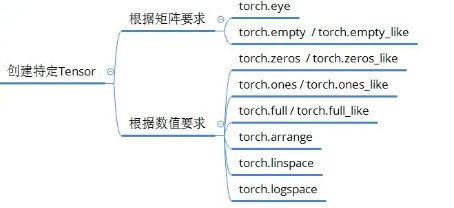

In [18]:
Image(filename='./Image/define_tensor.png',width=600)

### torch.eye 是 PyTorch 中的一个函数，用于创建一个单位矩阵（Identity Matrix）。
- 单位矩阵是一个方阵，其对角线上的元素为1，其余元素为0。
- 单位矩阵在矩阵运算中非常有用，
  - 例如在矩阵乘法中，单位矩阵作为乘法单位元，不会改变其他矩阵的值。

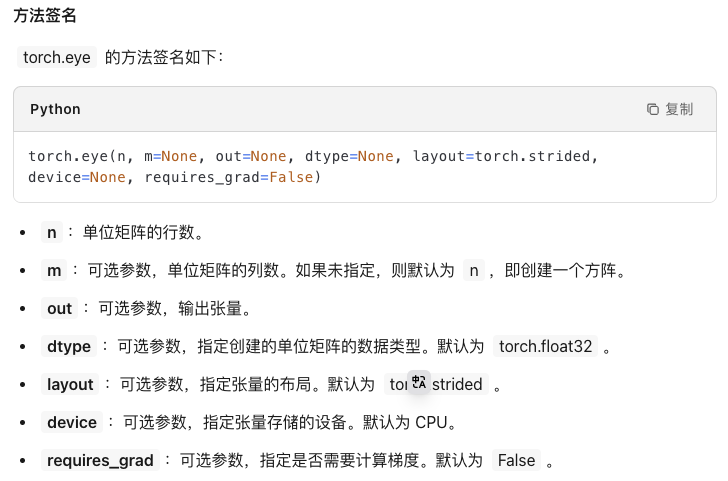

In [19]:
Image(filename='./Image/torch.eye.png',width=600)

In [20]:
import torch

# 创建一个 3x3 的单位矩阵
identity_matrix = torch.eye(3)
print(identity_matrix)
# 输出:
# tensor([[1., 0., 0.],
#         [0., 1., 0.],
#         [0., 0., 1.]])

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]])


In [21]:
# 创建一个 3x4 的单位矩阵
identity_matrix = torch.eye(3, 4)
print(identity_matrix)
# 输出:
# tensor([[1., 0., 0., 0.],
#         [0., 1., 0., 0.],
#         [0., 0., 1., 0.]])

tensor([[1., 0., 0., 0.],
        [0., 1., 0., 0.],
        [0., 0., 1., 0.]])


In [22]:
# 创建一个 3x3 的单位矩阵，指定数据类型为 torch.int64 和设备为 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
identity_matrix = torch.eye(3, dtype=torch.int64, device=device)
print(identity_matrix)
# 输出:
# tensor([[1, 0, 0],
#         [0, 1, 0],
#         [0, 0, 1]], device='cuda:0')

tensor([[1, 0, 0],
        [0, 1, 0],
        [0, 0, 1]])


In [23]:
# 创建一个 3x3 的单位矩阵，指定 requires_grad=True
identity_matrix = torch.eye(3, requires_grad=True)
print(identity_matrix)
# 输出:
# tensor([[1., 0., 0.],
#         [0., 1., 0.],
#         [0., 0., 1.]], requires_grad=True)

tensor([[1., 0., 0.],
        [0., 1., 0.],
        [0., 0., 1.]], requires_grad=True)


#### torch.empty 和 torch.empty_like

torch.empty 和 torch.empty_like 是 PyTorch 中用于创建未初始化张量的方法。
- 这些方法创建的张量不包含任何特定的值，其内容是随机的，取决于内存中的当前值。
- 这些方法在某些情况下非常有用，例如在需要分配内存但不立即初始化数据时。

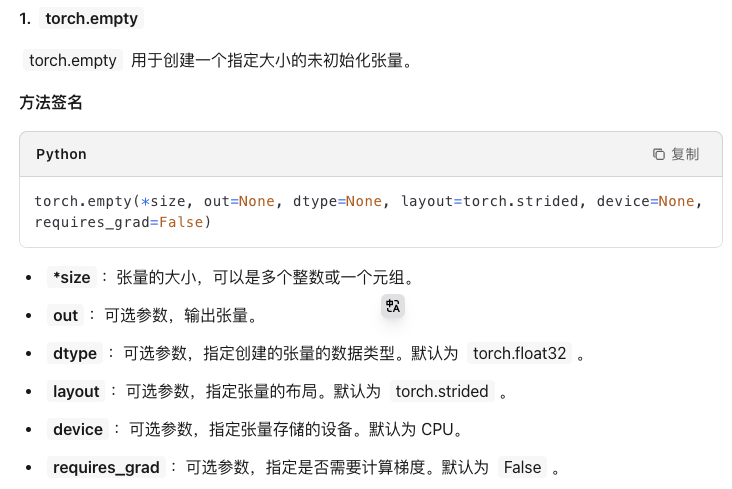

In [24]:
Image(filename='./Image/torch.empty.png',width=600)

In [25]:
import torch

# 创建一个 2x3 的未初始化张量
x = torch.empty(2, 3)
print(x)
# 输出: tensor([[1.2345e-38, 1.2345e-38, 1.2345e-38],
#               [1.2345e-38, 1.2345e-38, 1.2345e-38]])

# 创建一个 2x3 的未初始化张量，指定数据类型为 torch.int64
x = torch.empty(2, 3, dtype=torch.int64)
print(x)
# 输出: tensor([[4607182418800017408, 4607182418800017408, 4607182418800017408],
#               [4607182418800017408, 4607182418800017408, 4607182418800017408]])

# 创建一个 2x3 的未初始化张量，指定设备为 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.empty(2, 3, device=device)
print(x)
# 输出: tensor([[1.2345e-38, 1.2345e-38, 1.2345e-38],
#               [1.2345e-38, 1.2345e-38, 1.2345e-38]], device='cuda:0')

tensor([[0.0000e+00, 1.5846e+29, 7.0417e-25],
        [2.0005e+00, 8.4078e-45, 0.0000e+00]])
tensor([[         1065353223,                   0, 4575657221408423936],
        [                  0,                   0,          1065353216]])
tensor([[8.4078e-45, 1.8750e+00, 0.0000e+00],
        [1.8750e+00, 0.0000e+00, 1.8750e+00]])


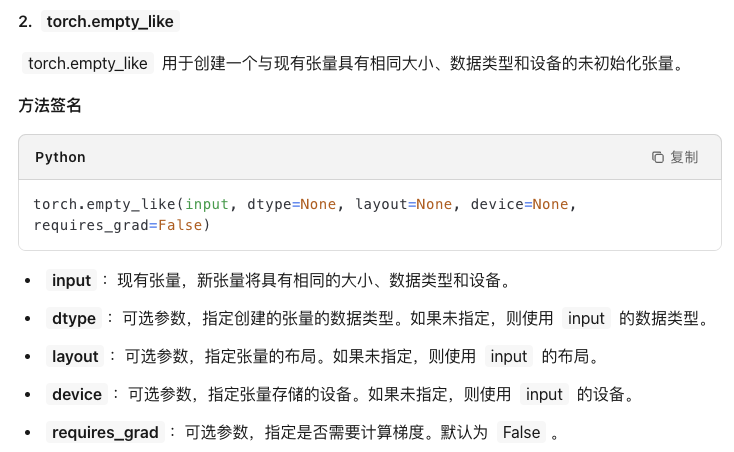

In [26]:
Image(filename='./Image/torch.empty_like.png',width=600)

In [28]:
import torch

# 创建一个现有的张量
x = torch.tensor([[1, 2], [3, 4]], dtype=torch.float32, device='cpu')

# 创建一个与 x 具有相同大小、数据类型和设备的未初始化张量
y = torch.empty_like(x)
print(y)
# 输出: tensor([[1.2345e-38, 1.2345e-38],
#               [1.2345e-38, 1.2345e-38]], device='cuda:0')

# 创建一个与 x 具有相同大小，但数据类型为 torch.int64 的未初始化张量
y = torch.empty_like(x, dtype=torch.int64)
print(y)
# 输出: tensor([[4607182418800017408, 4607182418800017408],
#               [4607182418800017408, 4607182418800017408]], device='cuda:0')

tensor([[0.0000e+00, 1.8750e+00],
        [5.2362e-34, 1.4013e-45]])
tensor([[3947405073390239750, 4611123068473966592],
        [4611123068473966592, 4611123068473966592]])


### torch.arange

在 PyTorch 中，torch.arange 是一个用于创建一维张量的函数，该张量包含从指定的起始值到结束值的连续整数。
- 这个函数类似于 NumPy 中的 np.arange，非常适用于生成序列数据。

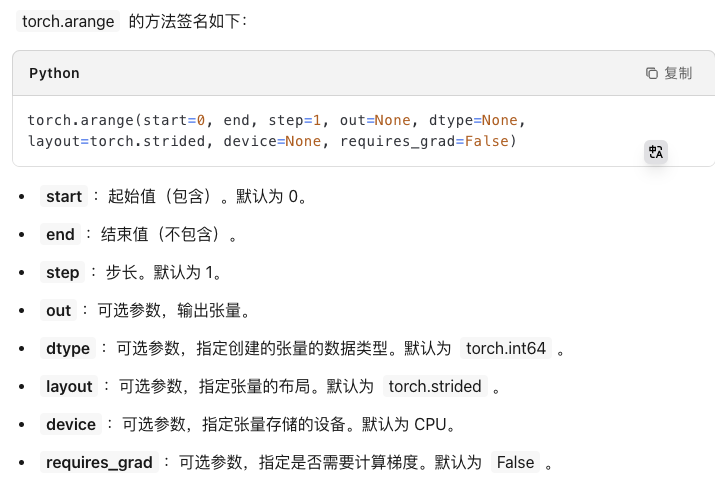

In [29]:
Image(filename='./Image/torch.arange.png',width=600)

注意事项
- 结束值不包含：
  - torch.arange 的结束值是不包含的，即生成的张量不会包含 end 值。
- 步长：
  - 步长可以是正数或负数。如果步长为负数，起始值必须大于结束值。
- 数据类型：
  - 默认情况下，torch.arange 创建的张量的数据类型是 torch.int64。如果需要其他数据类型，可以通过 dtype 参数指定。
- 设备：
  - 默认情况下，torch.arange 创建的张量存储在 CPU 上。如果需要将张量存储在 GPU 上，可以通过 device 参数指定。
- 梯度计算：
  - 如果需要在反向传播中使用这个张量，可以设置 requires_grad=True。

In [30]:
import torch

# 创建一个从 0 到 5 的张量
x = torch.arange(5)
print(x)
# 输出: tensor([0, 1, 2, 3, 4])

tensor([0, 1, 2, 3, 4])


In [31]:
# 创建一个从 1 到 5 的张量
x = torch.arange(1, 6)
print(x)
# 输出: tensor([1, 2, 3, 4, 5])

tensor([1, 2, 3, 4, 5])


In [32]:
# 创建一个从 0 到 10，步长为 2 的张量
x = torch.arange(0, 10, 2)
print(x)
# 输出: tensor([0, 2, 4, 6, 8])

tensor([0, 2, 4, 6, 8])


In [37]:
# 创建一个从 0 到 10，步长为 -2 的张量
x = torch.arange(10, 0, -2)
print(x)
# 输出: tensor([0, 2, 4, 6, 8])

tensor([10,  8,  6,  4,  2])


In [33]:
# 创建一个从 0 到 5 的张量，指定数据类型为 torch.float32 和设备为 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.arange(5, dtype=torch.float32, device=device)
print(x)
# 输出: tensor([0., 1., 2., 3., 4.], device='cuda:0')

tensor([0., 1., 2., 3., 4.])


In [35]:
# 创建一个从 0 到 5 的张量，指定 requires_grad=True
x = torch.arange(5, dtype=torch.float32,requires_grad=True)
print(x)
# 输出: tensor([0, 1, 2, 3, 4], requires_grad=True)

tensor([0., 1., 2., 3., 4.], requires_grad=True)


### torch.linspace
torch.linspace 是 PyTorch 中的一个函数，用于创建一个包含在指定区间内均匀分布的值的一维张量。
- 这个函数类似于 NumPy 中的 np.linspace，非常适用于生成等间隔的序列数据，
- 例如在插值、绘图或生成测试数据时。

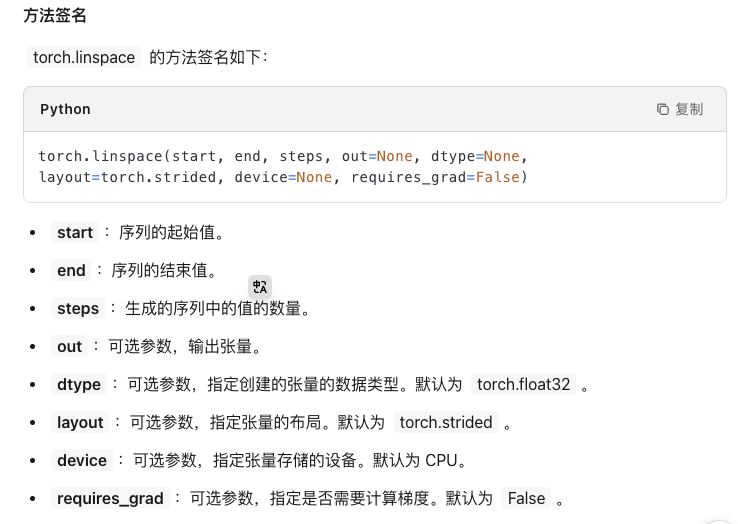

In [38]:
Image(filename='./Image/torch.linspace.png',width=600)

In [39]:
import torch

# 创建一个从 0 到 10 的等间隔序列，包含 5 个值
x = torch.linspace(0, 10, 5)
print(x)
# 输出: tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000])

tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000])


In [40]:
# 创建一个从 0 到 10 的等间隔序列，包含 5 个值，指定数据类型为 torch.float64 和设备为 GPU（如果可用）
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
x = torch.linspace(0, 10, 5, dtype=torch.float64, device=device)
print(x)
# 输出: tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000], device='cuda:0', dtype=torch.float64)

tensor([ 0.0000,  2.5000,  5.0000,  7.5000, 10.0000], dtype=torch.float64)


### torch.logspace 
torch.logspace 是 PyTorch 中的一个函数，
- 用于创建一个在对数刻度上均匀分布的值的一维张量。
- 这个函数类似于 NumPy 中的 np.logspace，非常适用于生成对数间隔的序列数据，
- 例如在科学计算、音频处理或生成对数刻度的数据时。

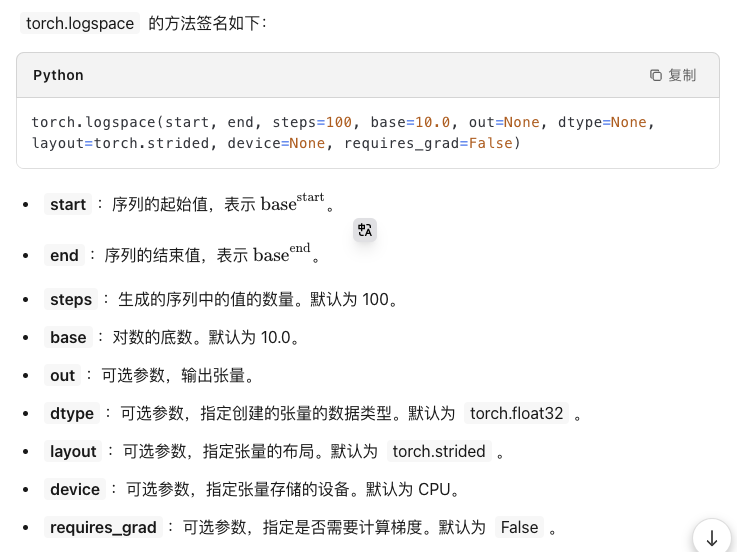

In [41]:
Image(filename='./Image/torch.logspace.png',width=600)

In [43]:
import torch

# 创建一个从 10^0 到 10^3 的对数间隔序列，包含 5 个值
x = torch.logspace(0, 3, 15)
print(x)
# 输出: tensor([   1.0000,   10.0000,  100.0000, 1000.0000])

tensor([   1.0000,    1.6379,    2.6827,    4.3940,    7.1969,   11.7877,
          19.3070,   31.6228,   51.7947,   84.8343,  138.9496,  227.5846,
         372.7594,  610.5402, 1000.0000])


In [46]:
# 创建一个从 2^0 到 2^3 的对数间隔序列，包含 5 个值，指定底数为 2
x = torch.logspace(0, 3, 5, base=2)
print(x)
# 输出: tensor([ 1.,  2.,  4.,  8.])

tensor([1.0000, 1.6818, 2.8284, 4.7568, 8.0000])


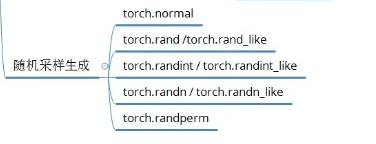

In [47]:
Image(filename='./Image/torch_random.png',width=600)

### torch.normal
torch.normal 是 PyTorch 中的一个函数，用于生成服从正态分布（高斯分布）的随机数。
- 这个函数非常适用于初始化神经网络的权重、生成随机噪声等场景。

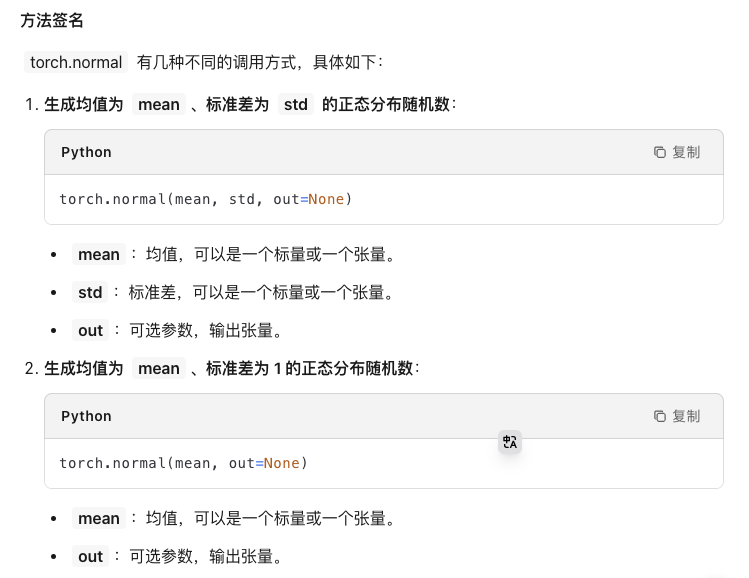

In [48]:
Image(filename='./Image/torch.normal_01.png',width=600)

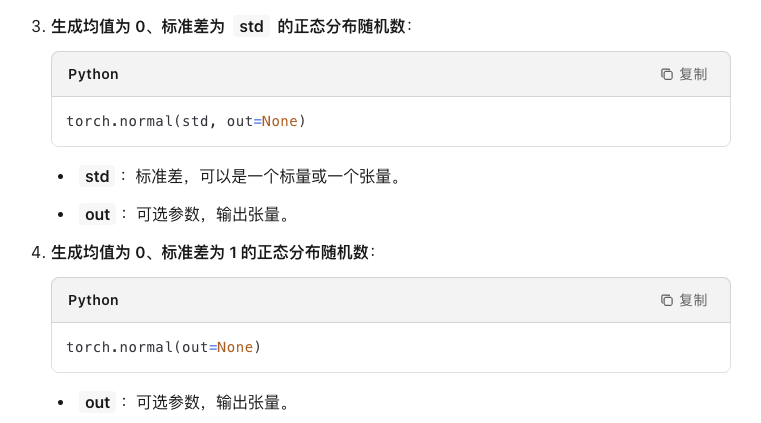

In [49]:
Image(filename='./Image/torch.normal_02.png',width=600)

In [50]:
import torch

# 生成一个形状为 (2, 3) 的正态分布随机数
x = torch.normal(0, 1, size=(2, 3))
print(x)
# 输出: tensor([[ 0.1234, -0.5678,  1.2345],
#               [-0.9876,  0.4321, -0.1234]])

tensor([[-1.8954, -0.2292, -1.4148],
        [-0.7766,  0.1935, -1.7692]])


In [51]:
# 生成一个形状为 (2, 3) 的正态分布随机数
x = torch.normal(2, 0.5, size=(2, 3))
print(x)
# 输出: tensor([[ 2.1234,  1.5678,  2.2345],
#               [ 1.9876,  2.4321,  1.8765]])

tensor([[1.1742, 2.6103, 1.4132],
        [2.3783, 2.0066, 2.5875]])


In [ ]:
# 使用张量作为均值和标准差
# 生成一个形状为 (2, 3) 的正态分布随机数，均值和标准差分别为两个张量
mean = torch.tensor([[1, 2, 3], [4, 5, 6]])
std = torch.tensor([[0.1, 0.2, 0.3], [0.4, 0.5, 0.6]])

x = torch.normal(mean, std)
print(x)
# 输出: tensor([[ 1.1234,  1.5678,  3.2345],
#               [ 4.9876,  5.4321,  6.8765]])

In [ ]:
# 生成的随机数是随机的，每次调用 torch.normal 都会生成不同的值。如果需要生成可重复的随机数，可以设置随机种子：

torch.manual_seed(42)
x = torch.normal(0, 1, size=(2, 3))

#### torch.rand 

torch.rand 是 PyTorch 中的一个函数，用于生成服从均匀分布的随机数。
- 这些随机数在区间 [0,1) 内均匀分布。
- torch.rand 非常适用于初始化张量、生成随机噪声等场景。

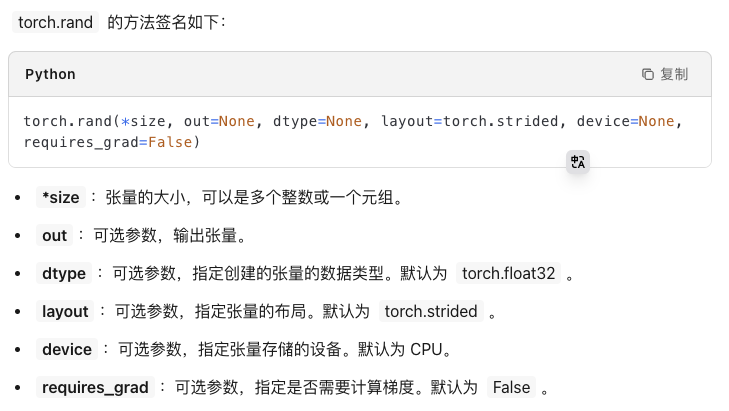

In [52]:
Image(filename='./Image/torch.rand.png',width=600)

In [ ]:
import torch

# 生成一个形状为 (2, 3) 的随机张量
x = torch.rand(2, 3)
print(x)
# 输出: tensor([[0.1234, 0.5678, 0.9012],
#               [0.3456, 0.7890, 0.2345]])

#### torch.randint 
torch.randint 是 PyTorch 中的一个函数，用于生成服从均匀分布的随机整数。
- 这些随机整数在指定的区间内均匀分布，
- 非常适用于生成随机索引、随机标签或初始化整数类型的张量。

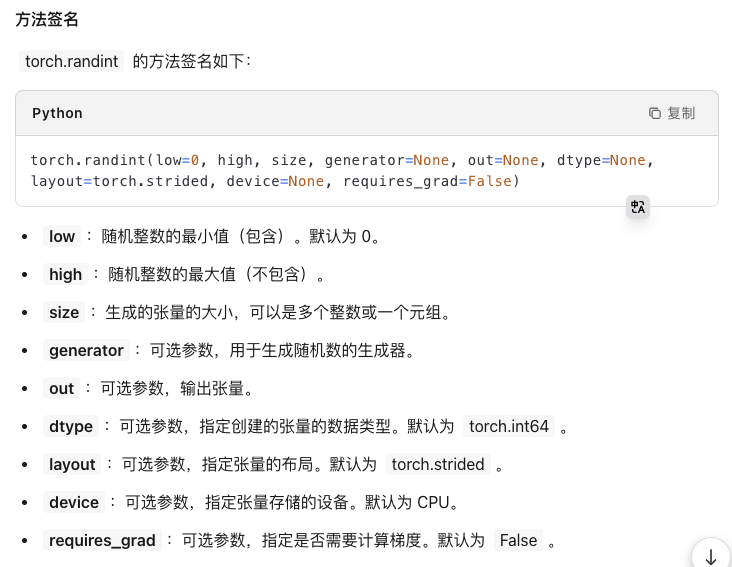

In [53]:
Image(filename='./Image/torch.randint.png',width=600)

In [ ]:
import torch

# 生成一个形状为 (2, 3) 的随机整数张量，值在 [0, 10) 区间内
x = torch.randint(0, 10, (2, 3))
print(x)
# 输出: tensor([[1, 5, 7],
#               [3, 9, 2]])

In [ ]:
# 生成一个形状为 (2, 3) 的随机整数张量，值在 [5, 15) 区间内
x = torch.randint(5, 15, (2, 3))
print(x)
# 输出: tensor([[ 6, 13,  8],
#               [14,  9, 11]])

#### torch.randn
torch.randn 是 PyTorch 中的一个函数，
- 用于生成服从标准正态分布（均值为 0，标准差为 1）的随机数。
- 这个函数非常适用于初始化神经网络的权重、生成随机噪声等场景。

In [54]:
import torch

# 生成一个形状为 (2, 3) 的标准正态分布随机张量
x = torch.randn(2, 3)
print(x)
# 输出: tensor([[ 0.1234, -0.5678,  1.2345],
#               [-0.9876,  0.4321, -0.1234]])

tensor([[-0.9959,  0.8123, -1.2059],
        [ 0.6203,  0.8705, -1.3297]])


#### torch.randperm
torch.randperm 是 PyTorch 中的一个函数，
- 用于生成一个随机排列的整数序列。
- 这个函数非常适用于需要随机打乱数据索引的场景，例如在数据加载时随机打乱数据顺序。


In [55]:
import torch

# 生成一个长度为 5 的随机排列
x = torch.randperm(5)
print(x)
# 输出: tensor([4, 1, 3, 2, 0])

tensor([2, 3, 4, 1, 0])


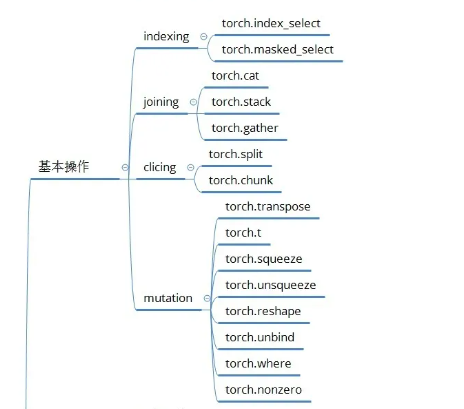

In [56]:
Image(filename='./Image/torch_basic.png',width=600)

#### torch.index_select

在 PyTorch 中，torch.index_select 是一个用于从张量中选择特定索引的函数。
- 它允许你根据指定的索引从张量中选择特定的行或列，这在许多场景中非常有用，例如在数据预处理、模型训练和评估中。

注意事项
- 索引必须是一维的：
  - index 参数必须是一个一维张量，包含要选择的索引。
- 索引的值必须在有效范围内：
  - index 中的值必须在输入张量的指定维度的有效范围内。例如，如果 dim=0，则索引值必须在 [0, input.size(0)) 范围内。
- 索引可以重复：
  - index 中的值可以重复，这意味着可以选择同一个索引多次。
- 数据类型和设备：
  - 输入张量和索引张量可以有不同的数据类型和设备。torch.index_select 会自动处理这些情况。

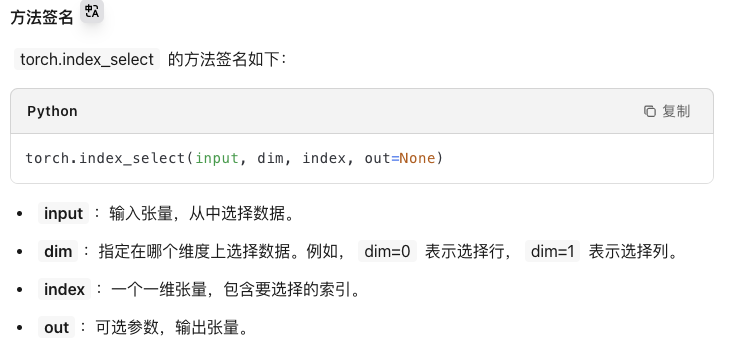

In [57]:
Image(filename='./Image/torch.index_select.png',width=600)

In [60]:
import torch

# 创建一个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# 选择第 0 行和第 2 行
indices = torch.tensor([0, 2])
selected_rows = torch.index_select(x, dim = 0 , index=indices)

print(selected_rows)
# 输出: tensor([[1, 2, 3],
#               [7, 8, 9]])

tensor([[1, 2, 3],
        [7, 8, 9]])


In [61]:
import torch

# 创建一个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# 选择第 0 行和第 2 行
indices = torch.tensor([0, 2])
selected_rows = torch.index_select(x, dim = 1 , index=indices)

print(selected_rows)


tensor([[1, 3],
        [4, 6],
        [7, 9]])


In [62]:
# 创建一个三维张量
x = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]], [[9, 10], [11, 12]]])

# 选择第 0 个和第 2 个切片
indices = torch.tensor([0, 2])
selected_slices = torch.index_select(x, dim=0, index=indices)

print(selected_slices)
# 输出: tensor([[[ 1,  2],
#                [ 3,  4]],
#
#               [[ 9, 10],
#                [11, 12]]])

tensor([[[ 1,  2],
         [ 3,  4]],

        [[ 9, 10],
         [11, 12]]])


#### torch.masked_select

torch.masked_select 是 PyTorch 中的一个函数，
- 用于根据一个布尔掩码（mask）从张量中选择元素。
- 这个函数非常适用于根据条件筛选数据，例如在数据预处理、模型训练和评估中。
- 输出张量是一个一维张量，包含所有被选择的元素。输出张量的形状取决于 mask 中 True 的数量。

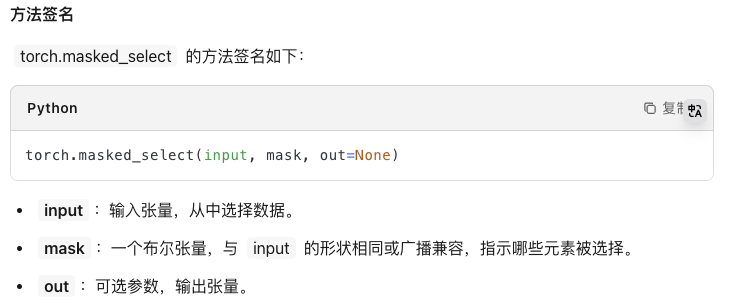

In [63]:
Image(filename='./Image/torch.masked_select.png',width=600)

In [64]:
import torch

# 创建一个一维张量
x = torch.tensor([1, 2, 3, 4, 5])

# 创建一个布尔掩码
mask = torch.tensor([True, False, True, False, True])

# 根据掩码选择元素
selected_elements = torch.masked_select(x, mask)

print(selected_elements)
# 输出: tensor([1, 3, 5])

tensor([1, 3, 5])


In [66]:
# 创建一个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# 创建一个布尔掩码
mask = torch.tensor([[True, False, True], [False, True, False], [True, False, True]])

# 根据掩码选择元素
selected_elements = torch.masked_select(x, mask)

print(selected_elements)
# 输出: tensor([1, 3, 5, 7, 9])

tensor([1, 3, 5, 7, 9])


In [65]:
# 创建一个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# 创建一个一维布尔掩码
mask = torch.tensor([True, False, True])

# 根据掩码选择元素（广播机制）
selected_elements = torch.masked_select(x, mask)

print(selected_elements)
# 输出: tensor([1, 3, 4, 6, 7, 9])

tensor([1, 3, 4, 6, 7, 9])


#### torch.cat

torch.cat 是 PyTorch 中的一个函数，
- 用于在指定维度上连接（拼接）多个张量。
- 这个函数非常适用于将多个张量合并成一个更大的张量，
- 例如在数据预处理、模型训练和评估中。
- dim 参数指定在哪个维度上进行拼接。
   - dim=0 表示在第一个维度上拼接，
   - dim=1 表示在第二个维度上拼接，依此类推。

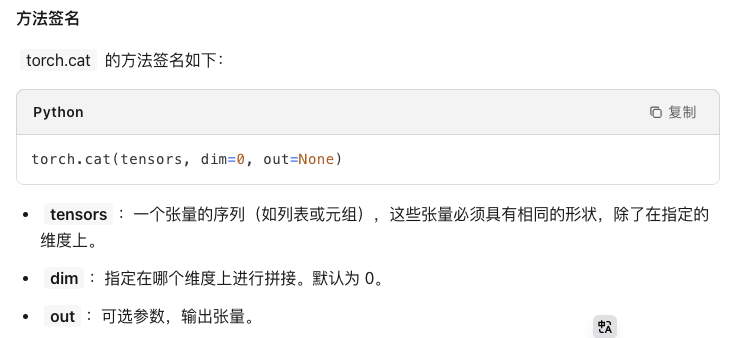

In [67]:
Image(filename='./Image/torch.cat.png',width=600)

In [71]:
import torch

# 创建两个张量
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])

# 在维度 0 上拼接
z = torch.cat((x, y), dim=0)

print(z)
# 输出: tensor([[1, 2],
#               [3, 4],
#               [5, 6],
#               [7, 8]])

tensor([[1, 2],
        [3, 4],
        [5, 6],
        [7, 8]])


In [72]:
print(x.shape)  # 输出: torch.Size([2, 3])
print(y.shape)  # 输出: torch.Size([2, 2])
# 在维度 1 上拼接
z = torch.cat((x, y), dim=1)

print(z)
# 输出: tensor([[1, 2, 5, 6],
#               [3, 4, 7, 8]])

torch.Size([2, 2])
torch.Size([2, 2])
tensor([[1, 2, 5, 6],
        [3, 4, 7, 8]])


In [ ]:
# 创建三个张量
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])
z = torch.tensor([[9, 10], [11, 12]])

# 在维度 0 上拼接
result = torch.cat((x, y, z), dim=0)

print(result)
# 输出: tensor([[ 1,  2],
#               [ 3,  4],
#               [ 5,  6],
#               [ 7,  8],
#               [ 9, 10],
#               [11, 12]])

#### torch.gather

torch.gather 是 PyTorch 中的一个函数，
- 用于根据索引从输入张量中选择数据。
- 它非常适用于根据特定的索引从张量中提取数据，
- 例如在数据预处理、模型训练和评估中。


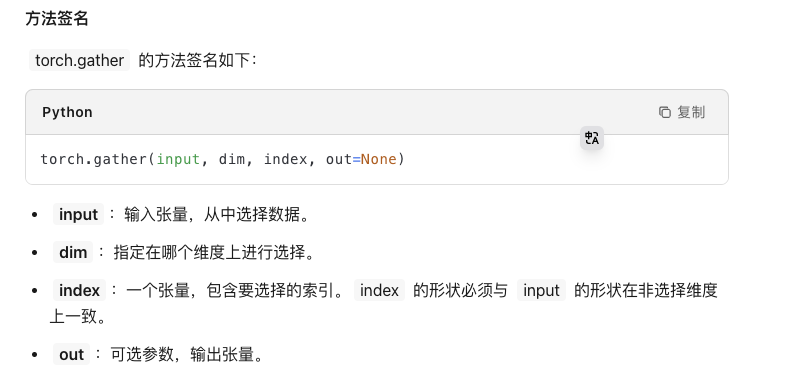

In [73]:
Image(filename='./Image/torch.gather.png',width=600)

In [ ]:
import torch

# 创建一个一维张量
x = torch.tensor([10, 20, 30, 40, 50])

# 创建一个索引张量
index = torch.tensor([0, 2, 4])

# 在维度 0 上选择元素
selected_elements = torch.gather(x, 0, index)

print(selected_elements)
# 输出: tensor([10, 30, 50])

In [ ]:
# 创建一个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9]])

# 创建一个索引张量
index = torch.tensor([[0, 2], [1, 2], [0, 1]])

# 在维度 1 上选择元素
selected_elements = torch.gather(x, 1, index)

print(selected_elements)
# 输出: tensor([[1, 3],
#               [5, 6],
#               [7, 8]])

In [ ]:
# 创建一个三维张量
x = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]], [[9, 10], [11, 12]]])

# 创建一个索引张量
index = torch.tensor([[[0, 1], [1, 0]], [[1, 0], [0, 1]], [[0, 1], [1, 0]]])

# 在维度 2 上选择元素
selected_elements = torch.gather(x, 2, index)

print(selected_elements)
# 输出: tensor([[[ 1,  4],
#                [ 3,  2]],
#
#               [[ 6,  5],
#                [ 7,  8]],
#
#               [[ 9, 12],
#                [11, 10]]])

#### torch.split

torch.split 是 PyTorch 中的一个函数，
- 用于将一个张量分割成多个较小的张量。
- 这个函数非常适用于将一个大的张量分成多个部分，例如在数据预处理、模型训练和评估中。


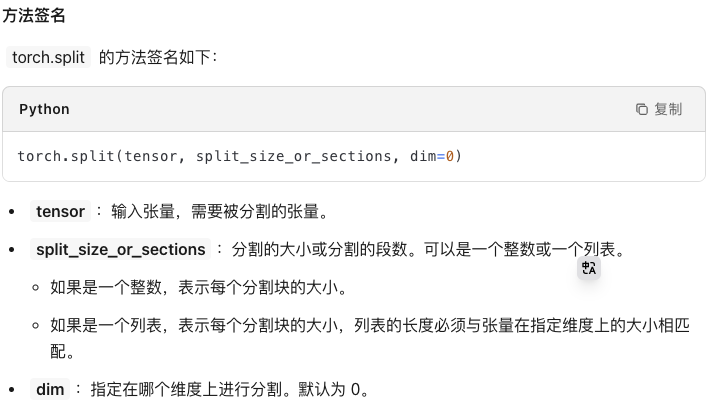

In [74]:
Image(filename='./Image/torch.split.png',width=600)

In [75]:
import torch

# 创建一个张量
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])

# 在维度 0 上分割成大小为 2 的块
splits = torch.split(x, 2, dim=0)

for split in splits:
    print(split)
# 输出:
# tensor([[1, 2, 3],
#         [4, 5, 6]])
# tensor([[ 7,  8,  9],
#         [10, 11, 12]])

tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[ 7,  8,  9],
        [10, 11, 12]])


In [76]:
# 在维度 1 上分割成大小为 1 的块
splits = torch.split(x, 1, dim=1)

for split in splits:
    print(split)
# 输出:
# tensor([[1],
#         [4],
#         [7],
#         [10]])
# tensor([[ 2],
#         [ 5],
#         [ 8],
#         [11]])
# tensor([[ 3],
#         [ 6],
#         [ 9],
#         [12]])

tensor([[ 1],
        [ 4],
        [ 7],
        [10]])
tensor([[ 2],
        [ 5],
        [ 8],
        [11]])
tensor([[ 3],
        [ 6],
        [ 9],
        [12]])


In [77]:
# 将一个张量在维度 0 上分割成指定大小的块
# 创建一个张量
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15]])

# 在维度 0 上分割成指定大小的块
splits = torch.split(x, [2, 1, 2], dim=0)

for split in splits:
    print(split)
# 输出:
# tensor([[1, 2, 3],
#         [4, 5, 6]])
# tensor([[7, 8, 9]])
# tensor([[10, 11, 12],
#         [13, 14, 15]])

tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[7, 8, 9]])
tensor([[10, 11, 12],
        [13, 14, 15]])


####  torch.chunk

torch.chunk 是 PyTorch 中的一个函数，用于将一个张量分割成指定数量的块。
- 与 torch.split 不同，torch.chunk 要求将张量分割成指定数量的块，而不是指定每个块的大小。
- 这使得 torch.chunk 在某些情况下更加方便，特别是在你希望将张量均匀分割时

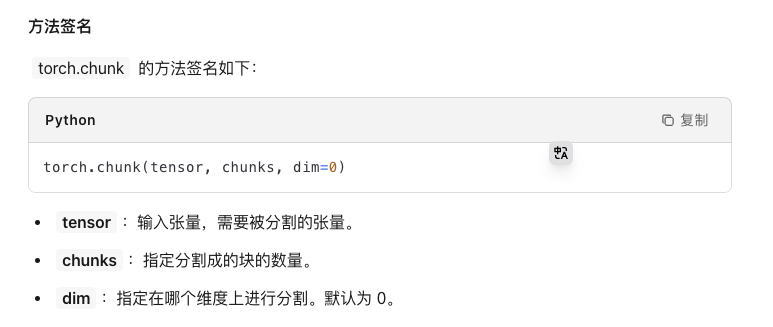

In [78]:
Image(filename='./Image/torch.chunk.png',width=600)

In [79]:
import torch

# 示例 1：将一个张量在维度 0 上分割成 2 个块

# 创建一个张量
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12]])

# 在维度 0 上分割成 2 个块
chunks = torch.chunk(x, 2, dim=0)

for chunk in chunks:
    print(chunk)
# 输出:
# tensor([[1, 2, 3],
#         [4, 5, 6]])
# tensor([[ 7,  8,  9],
#         [10, 11, 12]])

tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[ 7,  8,  9],
        [10, 11, 12]])


In [83]:
# 示例 2：将一个张量在维度 1 上分割成 3 个块

# 在维度 1 上分割成 3 个块
chunks = torch.chunk(x, 2, dim=1)

for chunk in chunks:
    print(chunk)
# 输出:
# tensor([[1],
#         [4],
#         [7],
#         [10]])
# tensor([[ 2],
#         [ 5],
#         [ 8],
#         [11]])
# tensor([[ 3],
#         [ 6],
#         [ 9],
#         [12]])

tensor([[ 1,  2],
        [ 4,  5],
        [ 7,  8],
        [10, 11]])
tensor([[ 3],
        [ 6],
        [ 9],
        [12]])


In [84]:
# 创建一个张量
x = torch.tensor([[1, 2, 3], [4, 5, 6], [7, 8, 9], [10, 11, 12], [13, 14, 15], [16, 17, 18]])

# 在维度 0 上分割成 3 个块
chunks = torch.chunk(x, 3, dim=0)

for chunk in chunks:
    print(chunk)
# 输出:
# tensor([[1, 2, 3],
#         [4, 5, 6]])
# tensor([[ 7,  8,  9],
#         [10, 11, 12]])
# tensor([[13, 14, 15],
#         [16, 17, 18]])

tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[ 7,  8,  9],
        [10, 11, 12]])
tensor([[13, 14, 15],
        [16, 17, 18]])


#### torch.transpose 

torch.transpose 是 PyTorch 中的一个函数，
- 用于交换张量的两个维度。
- 这个函数非常适用于对张量进行维度调整，例如在数据预处理、模型训练和评估中。
- 维度选择：dim0 和 dim1 必须是有效的维度索引，并且不能相同。
   - 例如，对于一个二维张量，dim0 和 dim1 可以是 0 和 1。

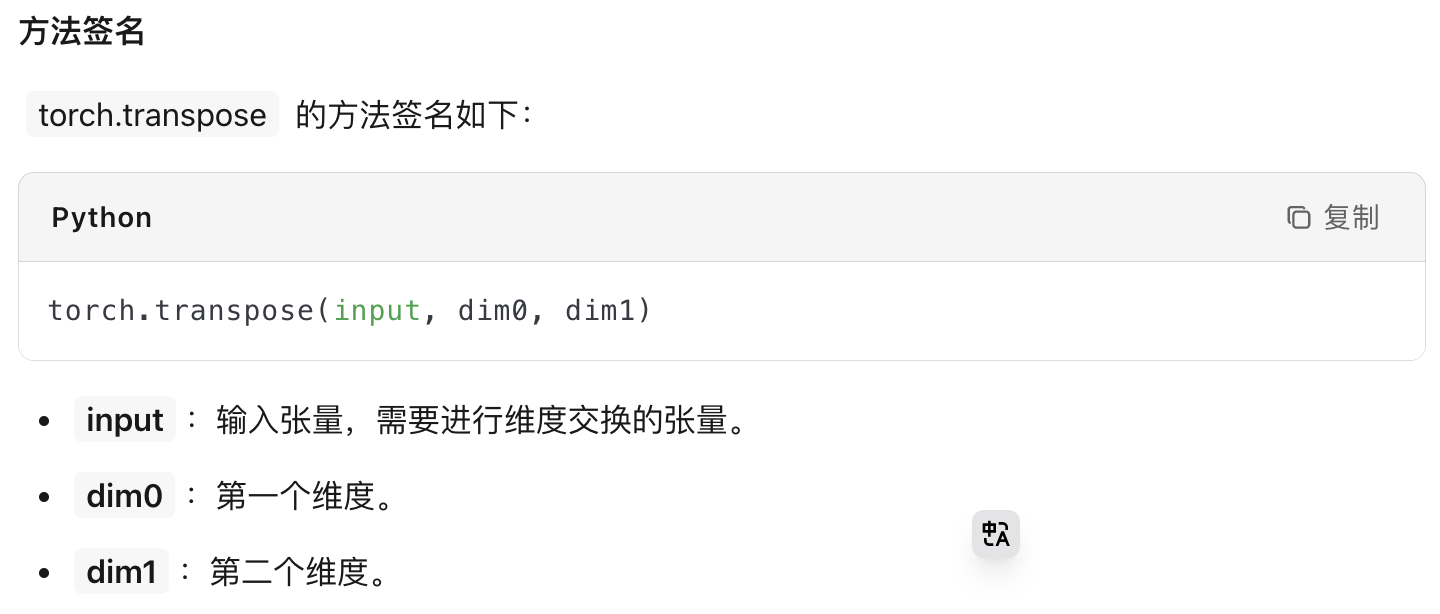

In [85]:
Image(filename='./Image/torch.transpose.png',width=600)

In [ ]:
import torch

# 创建一个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6]])

# 交换维度 0 和维度 1
x_transposed = torch.transpose(x, 0, 1)

print(x_transposed)
# 输出: tensor([[1, 4],
#               [2, 5],
#               [3, 6]])

In [86]:
# 交换三维张量的两个维度

# 创建一个三维张量
x = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

# 交换维度 1 和维度 2
x_transposed = torch.transpose(x, 1, 2)

print(x_transposed)
# 输出: tensor([[[1, 3],
#                [2, 4]],
#
#               [[5, 7],
#                [6, 8]]])

tensor([[[1, 3],
         [2, 4]],

        [[5, 7],
         [6, 8]]])


torch.transpose 不会修改原始张量，而是返回一个新的张量。
-  如果你希望原地交换维度，可以使用 transpose_ 方法：

In [ ]:
x.transpose_(0, 1)

### torch.t
torch.t 是 PyTorch 中的一个函数，用于对二维张量进行转置操作。
- 它是一个简化的版本，专门用于二维张量，可以快速交换张量的行和列。
- 对于更高维度的张量，可以使用 torch.transpose 或 torch.permute。

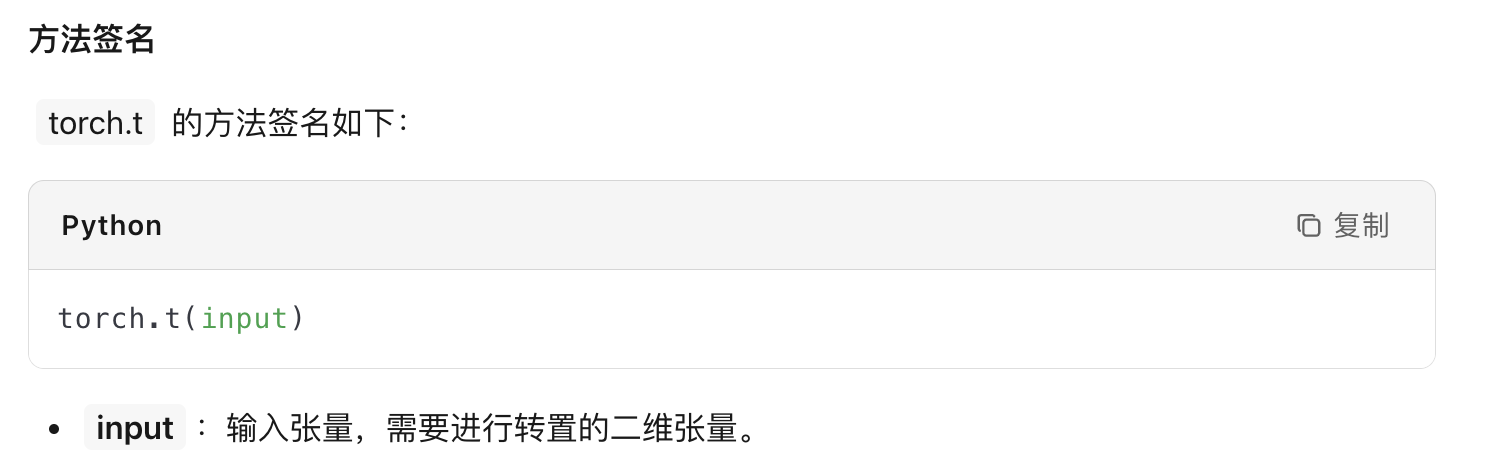

In [87]:
Image(filename='./Image/torch.t.png',width=600)

In [88]:
import torch

# 创建一个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6]])

# 转置张量
x_transposed = torch.t(x)

print(x_transposed)
# 输出: tensor([[1, 4],
#               [2, 5],
#               [3, 6]])

tensor([[1, 4],
        [2, 5],
        [3, 6]])


torch.t 只适用于二维张量。如果输入张量的维度不是 2，会抛出错误。例如：

In [89]:
x = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])  # 三维张量
x_transposed = torch.t(x)  # 会抛出错误

RuntimeError: t() expects a tensor with <= 2 dimensions, but self is 3D

torch.t 不会修改原始张量，而是返回一个新的张量。如果你希望原地转置张量，可以使用 t_ 方法：

In [ ]:
x.t_()

### torch.squeeze
torch.squeeze 是 PyTorch 中的一个函数，用于移除张量中大小为 1 的维度。
- 这个函数非常适用于简化张量的形状，特别是在处理批量数据或单个样本时。
- 如果指定 dim，只有当该维度的大小为 1 时，才会被压缩。如果该维度的大小不为 1，调用 torch.squeeze 时不会报错，但也不会对该维度进行压缩。

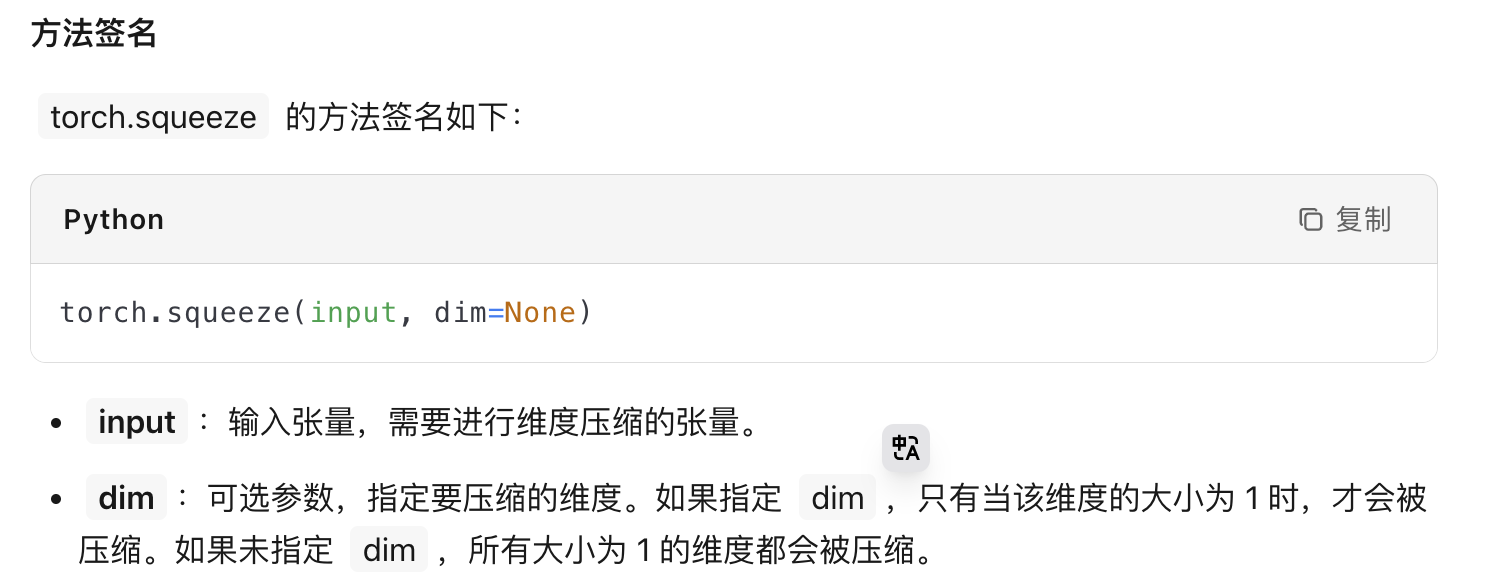

In [90]:
Image(filename='./Image/torch.squeeze.png',width=600)

In [91]:
import torch

# 创建一个张量
x = torch.tensor([[[1], [2], [3]]])

print(x.shape)  # 输出: torch.Size([1, 3, 1])

# 压缩所有大小为 1 的维度
x_squeezed = torch.squeeze(x)

print(x_squeezed.shape)  # 输出: torch.Size([3])
print(x_squeezed)        # 输出: tensor([1, 2, 3])

torch.Size([1, 3, 1])
torch.Size([3])
tensor([1, 2, 3])


In [92]:
# 示例 2：压缩指定维度

# 创建一个张量
x = torch.tensor([[[1], [2], [3]]])

print(x.shape)  # 输出: torch.Size([1, 3, 1])

# 压缩维度 0
x_squeezed_dim0 = torch.squeeze(x, dim=0)

print(x_squeezed_dim0.shape)  # 输出: torch.Size([3, 1])
print(x_squeezed_dim0)        # 输出: tensor([[1],
#                                            [2],
#                                            [3]])

# 压缩维度 2
x_squeezed_dim2 = torch.squeeze(x, dim=2)

print(x_squeezed_dim2.shape)  # 输出: torch.Size([1, 3])
print(x_squeezed_dim2)        # 输出: tensor([[1, 2, 3]])

torch.Size([1, 3, 1])
torch.Size([3, 1])
tensor([[1],
        [2],
        [3]])
torch.Size([1, 3])
tensor([[1, 2, 3]])


### torch.unsqueeze
torch.unsqueeze 是 PyTorch 中的一个函数，用于在指定位置插入一个大小为 1 的维度。
- 这个函数非常适用于调整张量的形状，特别是在需要增加维度以匹配其他张量的形状时。

In [93]:
# 在维度 0 上插入大小为 1 的维度
import torch

# 创建一个一维张量
x = torch.tensor([1, 2, 3])

print(x.shape)  # 输出: torch.Size([3])

# 在维度 0 上插入大小为 1 的维度
x_unsqueezed = torch.unsqueeze(x, 0)

print(x_unsqueezed.shape)  # 输出: torch.Size([1, 3])
print(x_unsqueezed)        # 输出: tensor([[1, 2, 3]])

torch.Size([3])
torch.Size([1, 3])
tensor([[1, 2, 3]])


In [94]:
# 示例 2：在维度 1 上插入大小为 1 的维度
# 创建一个一维张量
x = torch.tensor([1, 2, 3])

print(x.shape)  # 输出: torch.Size([3])

# 在维度 1 上插入大小为 1 的维度
x_unsqueezed = torch.unsqueeze(x, 1)

print(x_unsqueezed.shape)  # 输出: torch.Size([3, 1])
print(x_unsqueezed)        # 输出: tensor([[1],
#                                         [2],
#                                         [3]])

torch.Size([3])
torch.Size([3, 1])
tensor([[1],
        [2],
        [3]])


In [95]:
# 示例 3：在维度 2 上插入大小为 1 的维度
# 创建一个二维张量
x = torch.tensor([[1, 2], [3, 4]])

print(x.shape)  # 输出: torch.Size([2, 2])

# 在维度 2 上插入大小为 1 的维度
x_unsqueezed = torch.unsqueeze(x, 2)

print(x_unsqueezed.shape)  # 输出: torch.Size([2, 2, 1])
print(x_unsqueezed)        # 输出: tensor([[[1],
#                                         [2]],
#
#                                        [[3],
#                                         [4]]])

torch.Size([2, 2])
torch.Size([2, 2, 1])
tensor([[[1],
         [2]],

        [[3],
         [4]]])


### torch.reshape
torch.reshape 是 PyTorch 中的一个函数，用于改变张量的形状，而不改变其数据。
- 这个函数非常适用于在数据预处理、模型训练和评估中调整张量的形状。

In [96]:
import torch

# 创建一个一维张量
x = torch.tensor([1, 2, 3, 4, 5, 6])

print(x.shape)  # 输出: torch.Size([6])

# 改变形状为 (2, 3)
x_reshaped = torch.reshape(x, (2, 3))

print(x_reshaped.shape)  # 输出: torch.Size([2, 3])
print(x_reshaped)        # 输出: tensor([[1, 2, 3],
#                                         [4, 5, 6]])

torch.Size([6])
torch.Size([2, 3])
tensor([[1, 2, 3],
        [4, 5, 6]])


In [ ]:
# 示例 2：改变多维张量的形状
# 创建一个二维张量
x = torch.tensor([[1, 2], [3, 4], [5, 6]])

print(x.shape)  # 输出: torch.Size([3, 2])

# 改变形状为 (2, 3)
x_reshaped = torch.reshape(x, (2, 3))

print(x_reshaped.shape)  # 输出: torch.Size([2, 3])
print(x_reshaped)        # 输出: tensor([[1, 2, 3],
#                                         [4, 5, 6]])

In [97]:
# 示例 3：使用 -1 自动计算维度
# 创建一个二维张量
x = torch.tensor([[1, 2], [3, 4], [5, 6]])

print(x.shape)  # 输出: torch.Size([3, 2])

# 改变形状为 (3, -1)，PyTorch 会自动计算第二个维度
x_reshaped = torch.reshape(x, (3, -1))

print(x_reshaped.shape)  # 输出: torch.Size([3, 2])
print(x_reshaped)        # 输出: tensor([[1, 2],
#                                         [3, 4],
#                                         [5, 6]])

torch.Size([3, 2])
torch.Size([3, 2])
tensor([[1, 2],
        [3, 4],
        [5, 6]])


### torch.unbind

torch.unbind 是 PyTorch 中的一个函数，用于将一个张量在指定维度上拆分成多个独立的张量。
- 这个函数非常适用于将多维张量拆分成多个低维张量，例如在数据预处理、模型训练和评估中。

In [98]:
# 示例 1：在维度 0 上拆分二维张量
import torch

# 创建一个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6]])

# 在维度 0 上拆分
x_unbound = torch.unbind(x, dim=0)

for tensor in x_unbound:
    print(tensor)
# 输出:
# tensor([1, 2, 3])
# tensor([4, 5, 6])

tensor([1, 2, 3])
tensor([4, 5, 6])


In [99]:
# 示例 2：在维度 1 上拆分二维张量
# 创建一个二维张量
x = torch.tensor([[1, 2, 3], [4, 5, 6]])

# 在维度 1 上拆分
x_unbound = torch.unbind(x, dim=1)

for tensor in x_unbound:
    print(tensor)
# 输出:
# tensor([1, 4])
# tensor([2, 5])
# tensor([3, 6])

tensor([1, 4])
tensor([2, 5])
tensor([3, 6])


In [100]:
# 示例 3：在维度 0 上拆分三维张量
# 创建一个三维张量
x = torch.tensor([[[1, 2], [3, 4]], [[5, 6], [7, 8]]])

# 在维度 0 上拆分
x_unbound = torch.unbind(x, dim=0)

for tensor in x_unbound:
    print(tensor)
# 输出:
# tensor([[1, 2],
#         [3, 4]])
# tensor([[5, 6],
#         [7, 8]])

tensor([[1, 2],
        [3, 4]])
tensor([[5, 6],
        [7, 8]])


### torch.where
torch.where 是 PyTorch 中的一个函数，用于根据条件选择性地从两个张量中选择数据。
- 它类似于 NumPy 中的 np.where 函数，非常适用于条件选择和数据操作。

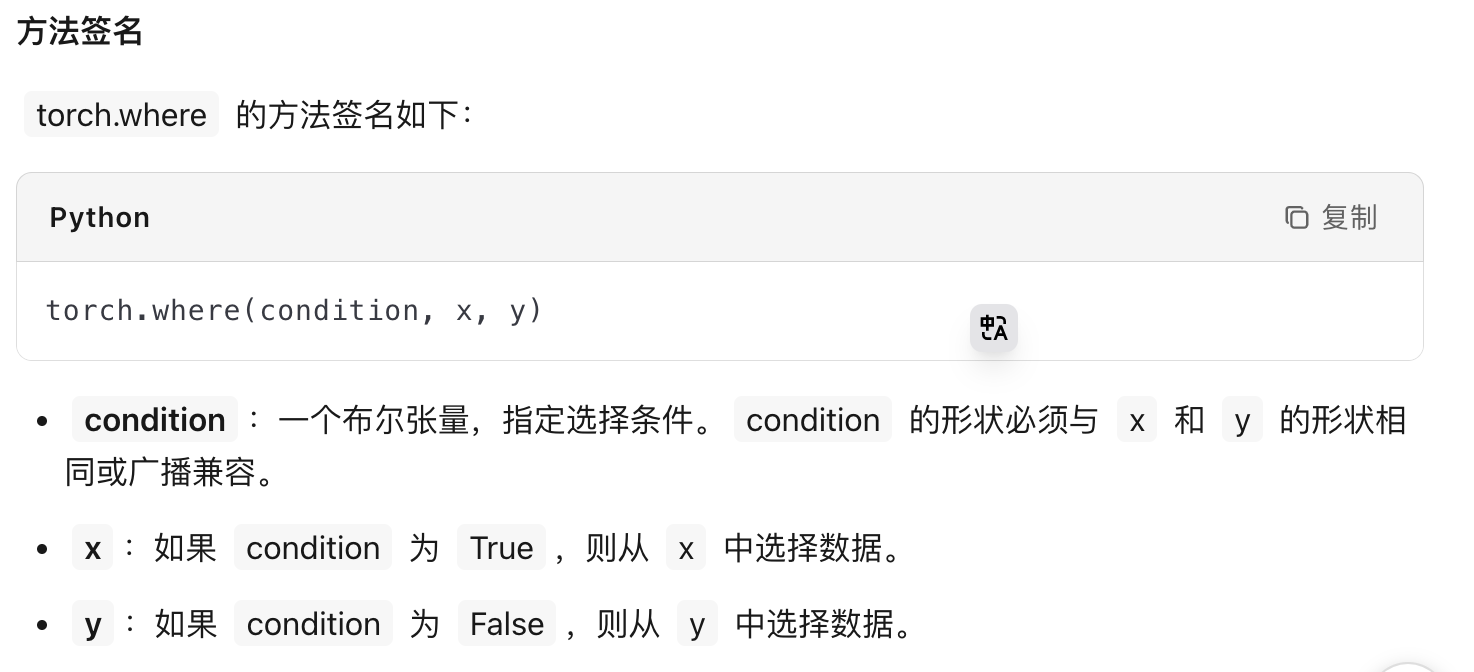

In [101]:
Image(filename='./Image/torch.where.png',width=600)

In [102]:
import torch

# 创建条件张量
condition = torch.tensor([[True, False], [False, True]])

# 创建两个数据张量
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([[5, 6], [7, 8]])

# 根据条件选择数据
result = torch.where(condition, x, y)

print(result)
# 输出: tensor([[1, 6],
#               [7, 4]])

tensor([[1, 6],
        [7, 4]])


In [103]:
# 示例 2：使用广播

# 创建条件张量
condition = torch.tensor([[True, False], [False, False]])

# 创建两个数据张量
x = torch.tensor([[1, 2], [3, 4]])
y = torch.tensor([5, 6])  # y 的形状为 (2,)，会自动广播

# 根据条件选择数据
result = torch.where(condition, x, y)

print(result)
# 输出: tensor([[1, 6],
#               [5, 4]])

tensor([[1, 6],
        [5, 6]])


In [ ]:
# 示例 3：条件选择
# 创建一个张量
x = torch.tensor([[1, 2], [3, 4]])

# 创建条件张量
condition = (x > 2)

# 根据条件选择数据
result = torch.where(condition, x, torch.tensor(0))

print(result)
# 输出: tensor([[0, 0],
#               [3, 4]])

### torch.nonzero
torch.nonzero 是 PyTorch 中的一个函数，用于返回输入张量中非零元素的索引。
- 这个函数非常适用于查找张量中非零元素的位置，例如在数据预处理、模型训练和评估中。

In [104]:
# 示例 1：查找一维张量中的非零元素索引
import torch

# 创建一个一维张量
x = torch.tensor([0, 1, 0, 3, 0, 5])

# 查找非零元素的索引
indices = torch.nonzero(x)

print(indices)
# 输出: tensor([[1],
#               [3],
#               [5]])

tensor([[1],
        [3],
        [5]])


In [ ]:
# 示例 2：查找二维张量中的非零元素索引

# 创建一个二维张量
x = torch.tensor([[0, 2, 0], [3, 0, 4]])

# 查找非零元素的索引
indices = torch.nonzero(x)

print(indices)
# 输出: tensor([[0, 1],
#               [1, 0],
#               [1, 2]])

In [ ]:

# 示例 3：使用 as_tuple=True 返回索引元组

# 创建一个二维张量
x = torch.tensor([[0, 2, 0], [3, 0, 4]])

# 查找非零元素的索引，返回元组
indices = torch.nonzero(x, as_tuple=True)

print(indices)
# 输出: (tensor([0, 1, 1]), tensor([1, 0, 2]))

### PyTorch 提供了一系列的三角函数，用于进行各种三角运算。

- 这些函数非常适用于数学计算、物理模拟和深度学习中的几何变换等场景。
- 以下是一些常见的三角函数及其使用方法：

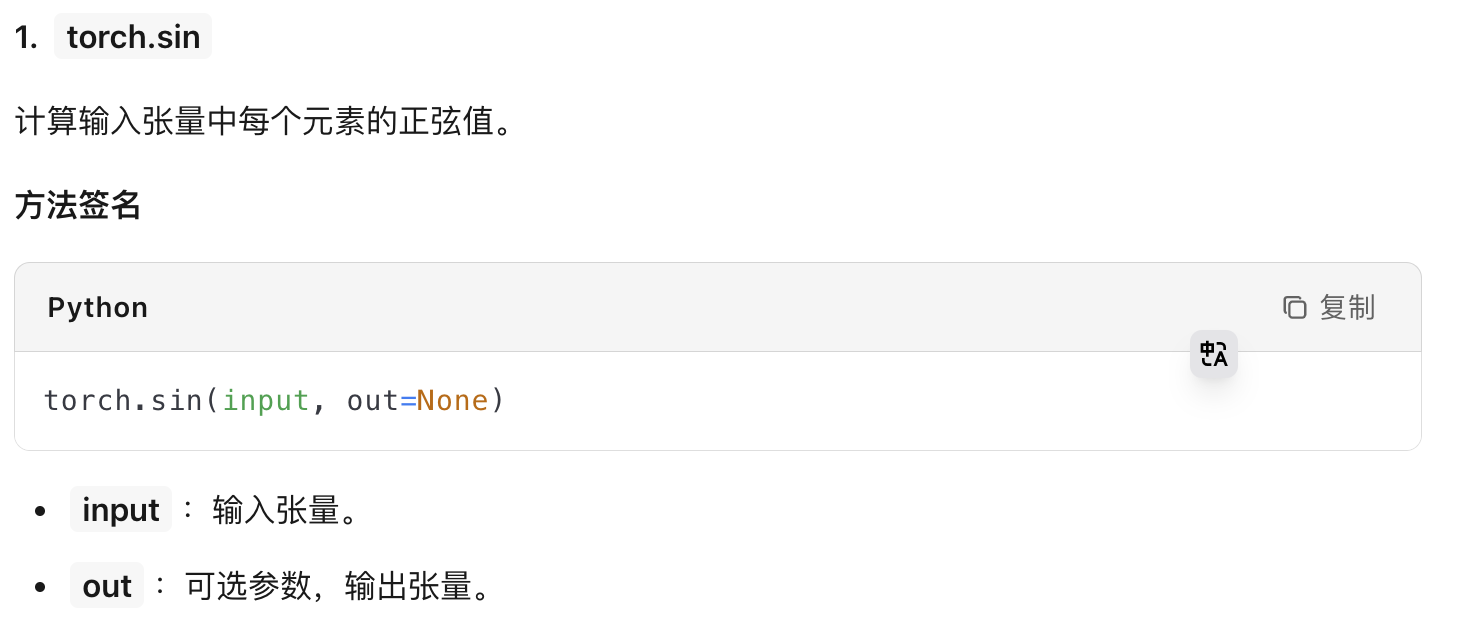

In [105]:
Image(filename='./Image/torch.sin.png',width=600)

In [106]:
import torch

# 创建一个张量
x = torch.tensor([0, torch.pi / 2, torch.pi])
print(x)

# 计算正弦值
y = torch.sin(x)

print(y)
# 输出: tensor([0.0000, 1.0000, 0.0000])

tensor([0.0000, 1.5708, 3.1416])
tensor([ 0.0000e+00,  1.0000e+00, -8.7423e-08])


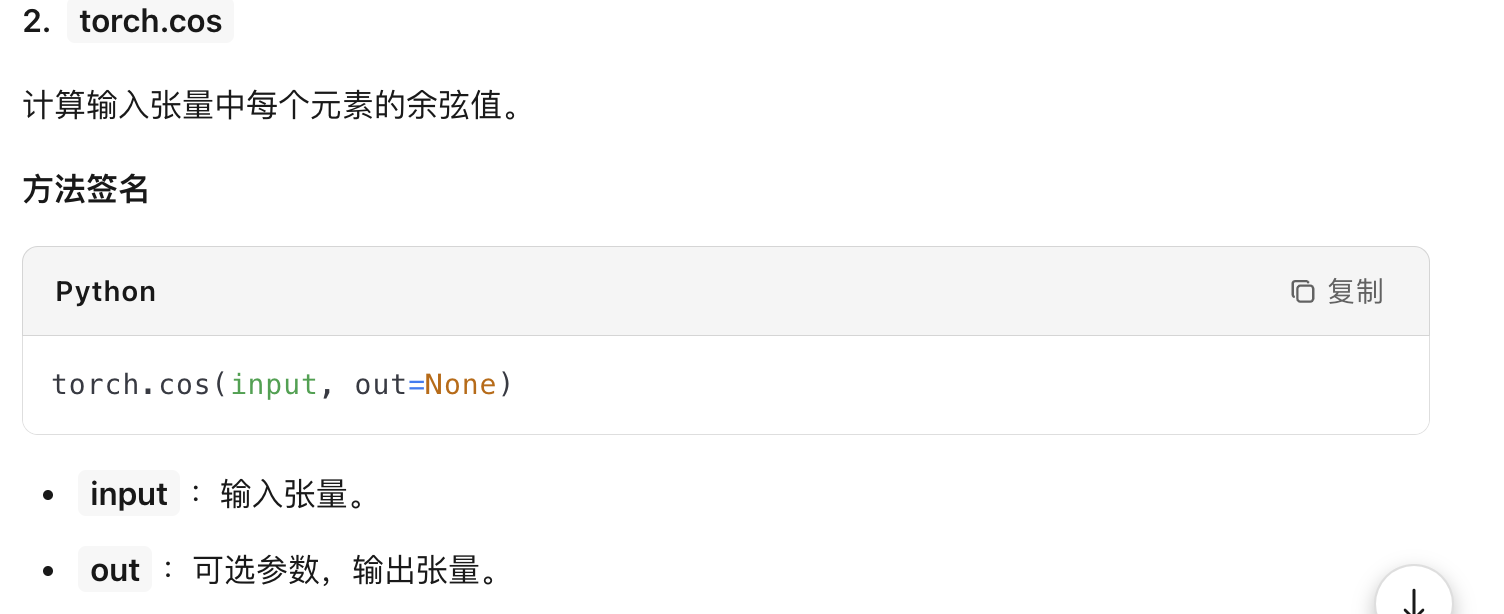

In [107]:
Image(filename='./Image/torch.cos.png',width=600)

In [ ]:
# 创建一个张量
x = torch.tensor([0, torch.pi / 2, torch.pi])

# 计算余弦值
y = torch.cos(x)

print(y)
# 输出: tensor([ 1.0000,  6.1232e-17, -1.0000])

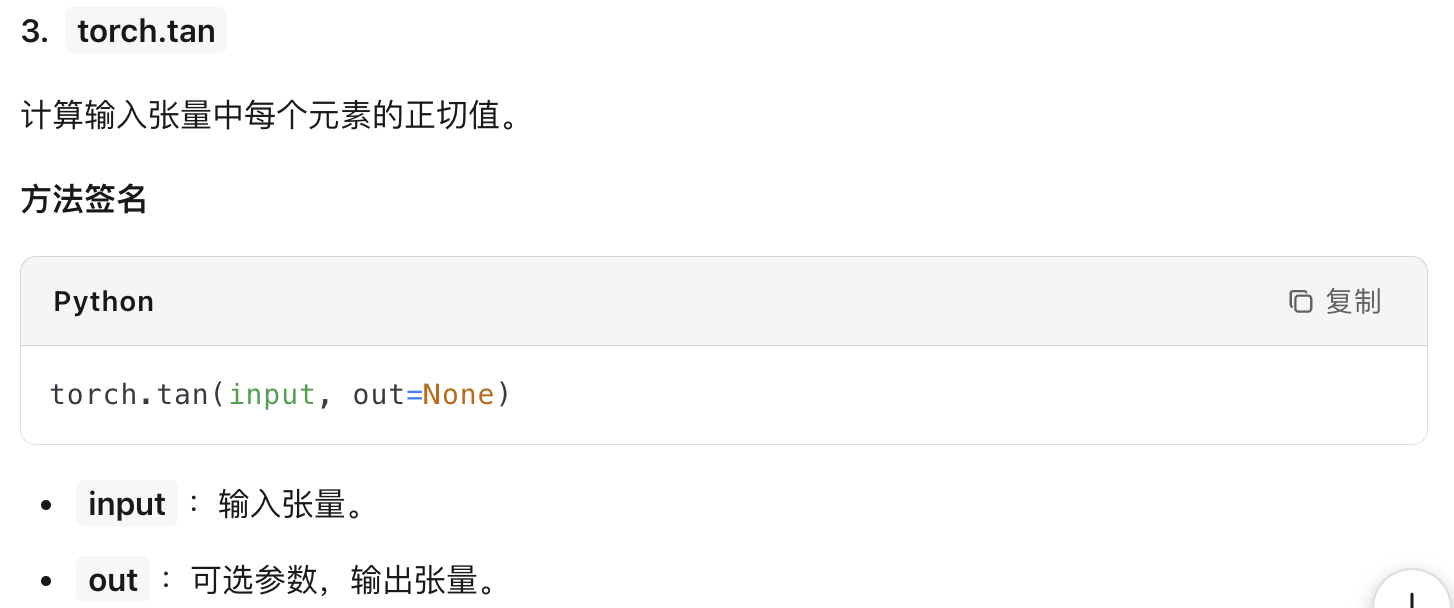

In [108]:
Image(filename='./Image/torch.tan.png',width=600)

In [ ]:
# 创建一个张量
x = torch.tensor([0, torch.pi / 4, torch.pi / 2])

# 计算正切值
y = torch.tan(x)

print(y)
# 输出: tensor([0.0000, 1.0000, 1.6331e+16])

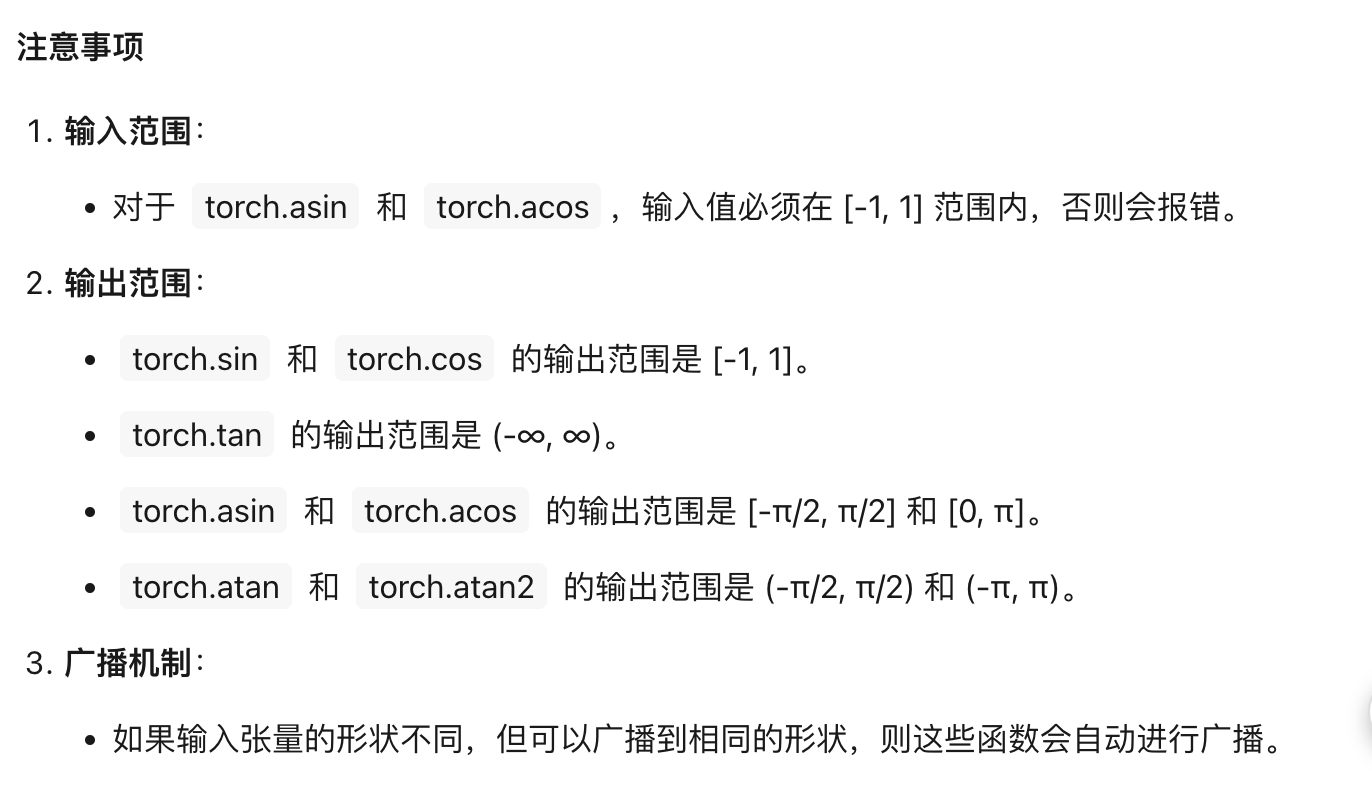

In [109]:
Image(filename='./Image/tan_notice.png',width=600)

### PyTorch 提供了一系列基本的数学运算，包括加法、减法、乘法和除法。
- 这些运算非常适用于张量之间的元素级操作，例如在数据预处理、模型训练和评估中。
以下是一些常见的加减乘除操作及其使用方法。

In [ ]:
import torch

# 创建两个张量
x = torch.tensor([1, 2, 3])
y = torch.tensor([4, 5, 6])

# 逐元素加法
z = torch.add(x, y)

print(z)
# 输出: tensor([5, 7, 9])

In [ ]:
# 创建两个张量
x = torch.tensor([1, 2, 3])
y = torch.tensor([4, 5, 6])

# 逐元素减法
z = torch.sub(x, y)

print(z)
# 输出: tensor([-3, -3, -3])

In [ ]:
# 创建两个张量
x = torch.tensor([1, 2, 3])
y = torch.tensor([4, 5, 6])

# 逐元素乘法
z = torch.mul(x, y)

print(z)
# 输出: tensor([ 4, 10, 18])

In [ ]:
# 创建两个张量
x = torch.tensor([1.0, 2.0, 3.0])
y = torch.tensor([4.0, 5.0, 6.0])

# 逐元素除法
z = torch.div(x, y)

print(z)
# 输出: tensor([0.2500, 0.4000, 0.5000])

In [ ]:
# 广播机制：如果输入张量的形状不同，但可以广播到相同的形状，则这些函数会自动进行广播。例如：

x = torch.tensor([1, 2, 3])
y = torch.tensor(2)
z = torch.add(x, y)
print(z)
# 输出: tensor([3, 4, 5])

### PyTorch 提供了多种对数运算函数，用于计算张量中每个元素的对数值。
- 这些函数非常适用于数学计算、数据预处理和模型训练中的对数变换。
- 以下是一些常见的对数运算函数及其使用方法：


#### 1. 自然对数（torch.log）计算输入张量中每个元素的自然对数（以 e 为底）。

In [ ]:
import torch

# 创建一个张量
x = torch.tensor([1.0, 2.0, 3.0])

# 计算自然对数
y = torch.log(x)

print(y)
# 输出: tensor([0.0000, 0.6931, 1.0986])

#### 2. 以 2 为底的对数（torch.log2）计算输入张量中每个元素的以 2 为底的对数。

In [110]:
# 创建一个张量
x = torch.tensor([1.0, 2.0, 4.0])

# 计算以 2 为底的对数
y = torch.log2(x)

print(y)
# 输出: tensor([0., 1., 2.])

tensor([0., 1., 2.])


#### 3. 以 10 为底的对数（torch.log10）计算输入张量中每个元素的以 10 为底的对数。

In [ ]:
# 创建一个张量
x = torch.tensor([1.0, 10.0, 100.0])

# 计算以 10 为底的对数
y = torch.log10(x)

print(y)
# 输出: tensor([0., 1., 2.])

#### 4. 对数1p（torch.log1p）计算输入张量中每个元素的 log(1+x)。
- 这个函数在 x 接近 0 时非常稳定，避免了数值问题。

In [ ]:
# 创建一个张量
x = torch.tensor([0.0, 0.1, 0.01])

# 计算 log(1 + x)
y = torch.log1p(x)

print(y)
# 输出: tensor([0.0000, 0.0953, 0.0099])

这些函数都有对应的原地操作版本，例如 log_、log2_、log10_ 和 log1p_。
- 这些原地操作会直接修改输入张量，而不是返回一个新的张量。例如：

In [111]:
x = torch.tensor([1.0, 2.0, 3.0])
x.log_()
print(x)
# 输出: tensor([0.0000, 0.6931, 1.0986])

tensor([0.0000, 0.6931, 1.0986])


#### 幂运算

在 PyTorch 中，幂运算可以通过多种方式实现，包括逐元素的幂运算和矩阵的幂运算。以下是一些常见的幂运算函数及其使用方法：

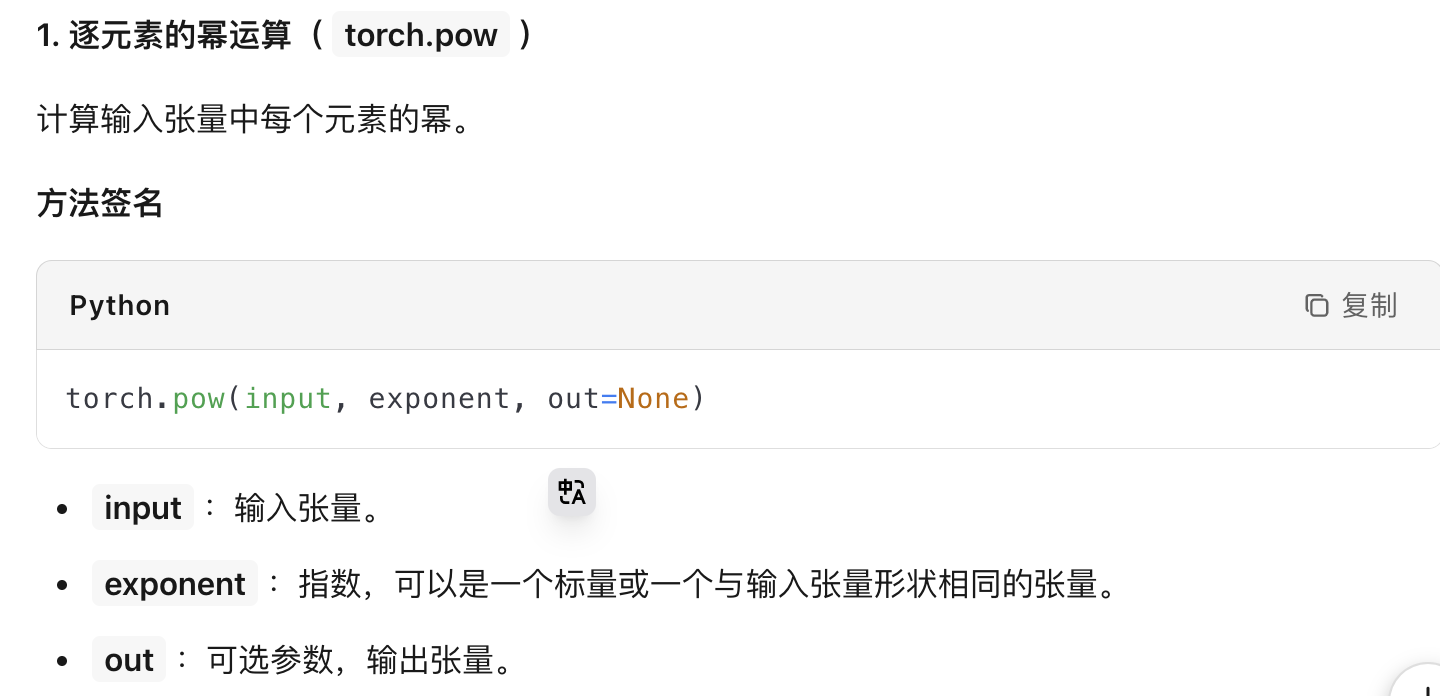

In [112]:
Image(filename='./Image/torch.pow.png',width=600)

In [114]:
import torch

# 创建一个张量
x = torch.tensor([1.0, 2.0, 3.0])

# 计算每个元素的平方
y = torch.pow(x, 3)

print(y)
# 输出: tensor([1., 4., 9.])

tensor([ 1.,  8., 27.])


In [115]:
# 示例：使用张量作为指数
# 创建两个张量
x = torch.tensor([1.0, 2.0, 3.0])
exp = torch.tensor([2.0, 3.0, 4.0])

# 计算每个元素的幂
y = torch.pow(x, exp)

print(y)
# 输出: tensor([ 1.,  8., 81.])

tensor([ 1.,  8., 81.])


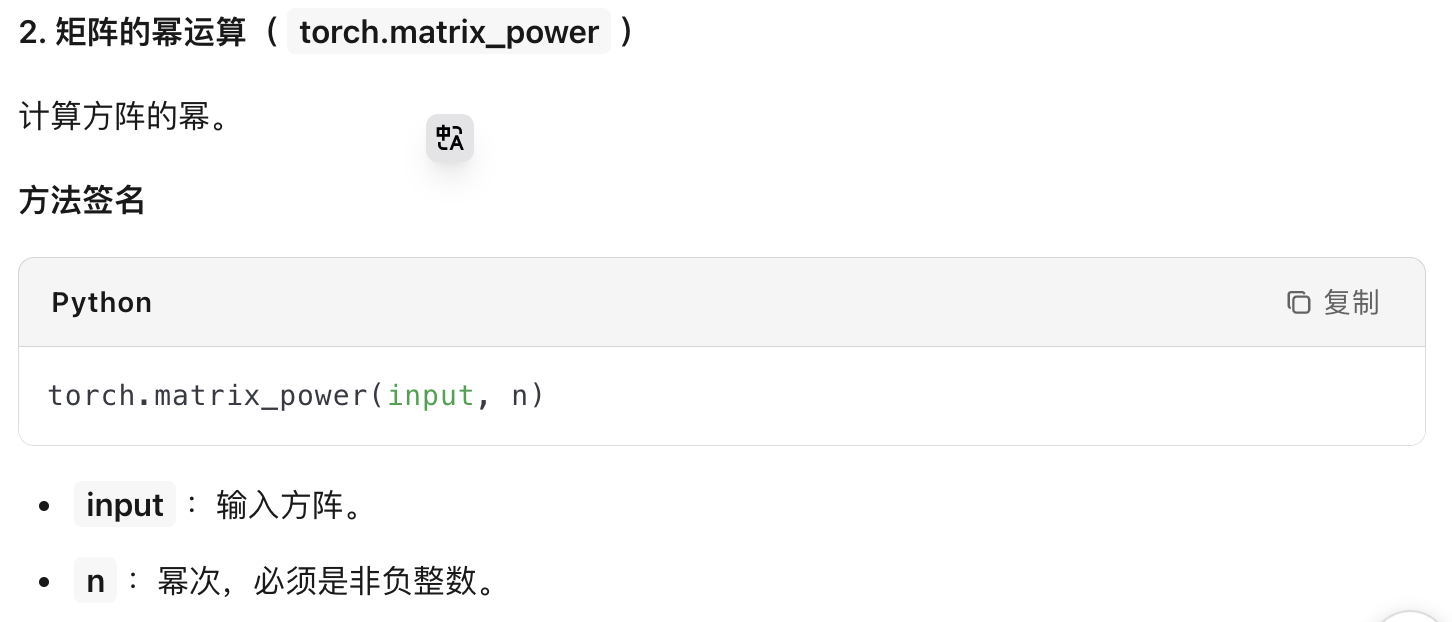

In [116]:
Image(filename='./Image/matrix_power.png',width=600)

In [ ]:
# 创建一个方阵
x = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

# 计算矩阵的平方
y = torch.matrix_power(x, 2)

print(y)
# 输出: tensor([[ 7., 10.],
#               [15., 22.]])

#### 幂运算的原地版本（torch.pow_）
- 逐元素的幂运算的原地版本，直接修改输入张量。

In [117]:
# 创建一个张量
x = torch.tensor([1.0, 2.0, 3.0])

# 计算每个元素的平方，原地修改
x.pow_(2)

print(x)
# 输出: tensor([1., 4., 9.])

tensor([1., 4., 9.])


#### 指数运算
- 在 PyTorch 中，指数运算可以通过多种方式实现，包括逐元素的指数运算和矩阵的指数运算。
- 以下是一些常见的指数运算函数及其使用方法：

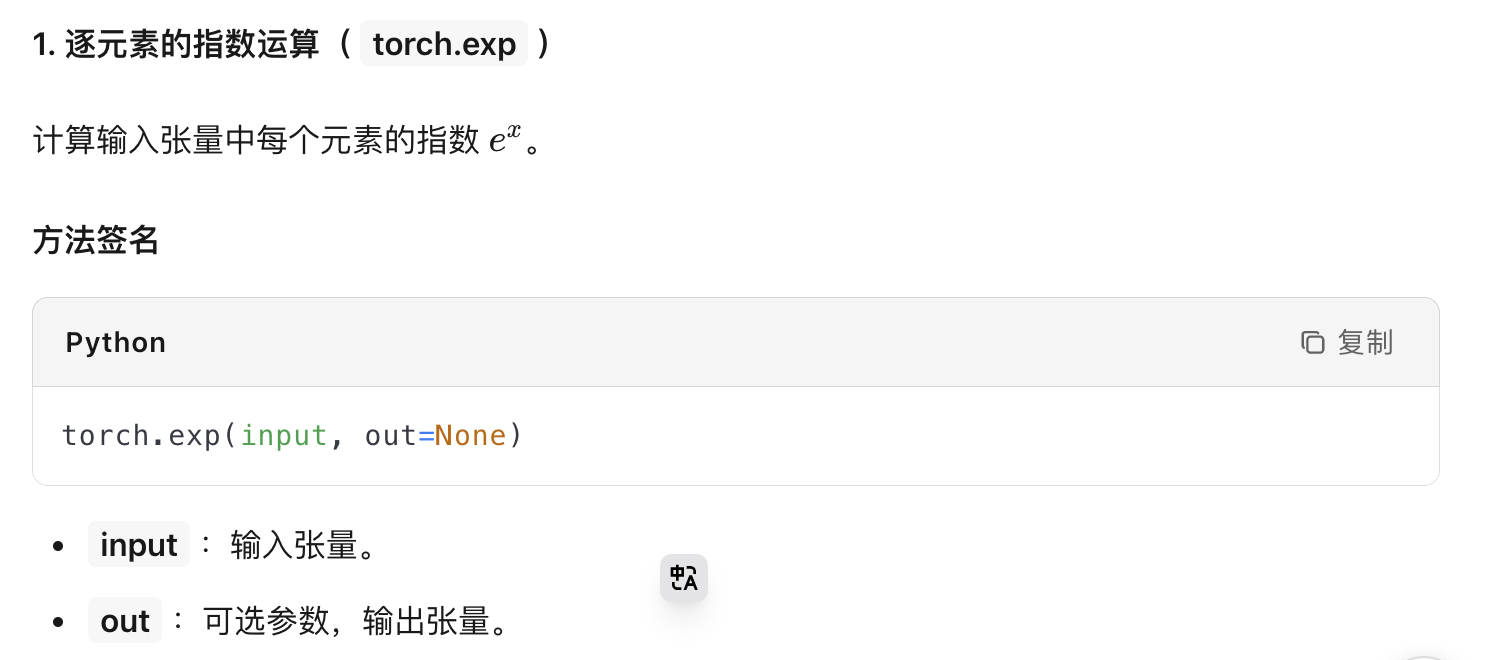

In [118]:
Image(filename='./Image/torch.exp.png',width=600)

In [ ]:
import torch

# 创建一个张量
x = torch.tensor([0.0, 1.0, 2.0])

# 计算每个元素的指数
y = torch.exp(x)

print(y)
# 输出: tensor([1.0000, 2.7183, 7.3891])

#### 2. 逐元素的指数减 1 运算（torch.expm1）
- 计算输入张量中每个元素的 $e^x −1$。
- 这个函数在 x 接近 0 时非常稳定，避免了数值问题。


In [ ]:
# 创建一个张量
x = torch.tensor([0.0, 1.0, 2.0])

# 计算每个元素的 e^x - 1
y = torch.expm1(x)

print(y)
# 输出: tensor([0.0000, 1.7183, 6.3891])

#### 矩阵的指数运算（torch.matrix_exp）
- 计算方阵的矩阵指数 $e^A$，其中 A 是一个方阵。

In [ ]:
# 创建一个方阵
A = torch.tensor([[1.0, 2.0], [3.0, 4.0]])

# 计算矩阵的指数
exp_A = torch.matrix_exp(A)

print(exp_A)
# 输出: tensor([[51.9689, 74.7366],
#               [112.1049, 164.0738]])

#### 逐元素的指数运算的原地版本（torch.exp_）
- 逐元素的指数运算的原地版本，直接修改输入张量。

In [119]:
# 创建一个张量
x = torch.tensor([0.0, 1.0, 2.0])

# 计算每个元素的指数，原地修改
x.exp_()

print(x)
# 输出: tensor([1.0000, 2.7183, 7.3891])

tensor([1.0000, 2.7183, 7.3891])


### torch.clamp

在 PyTorch 中，截断函数（Clamp Function）用于将输入张量中的每个元素限制在指定的范围内。
- 这在防止数值溢出、数据归一化和激活函数中非常有用。PyTorch 提供了 torch.clamp 函数来实现这一功能。


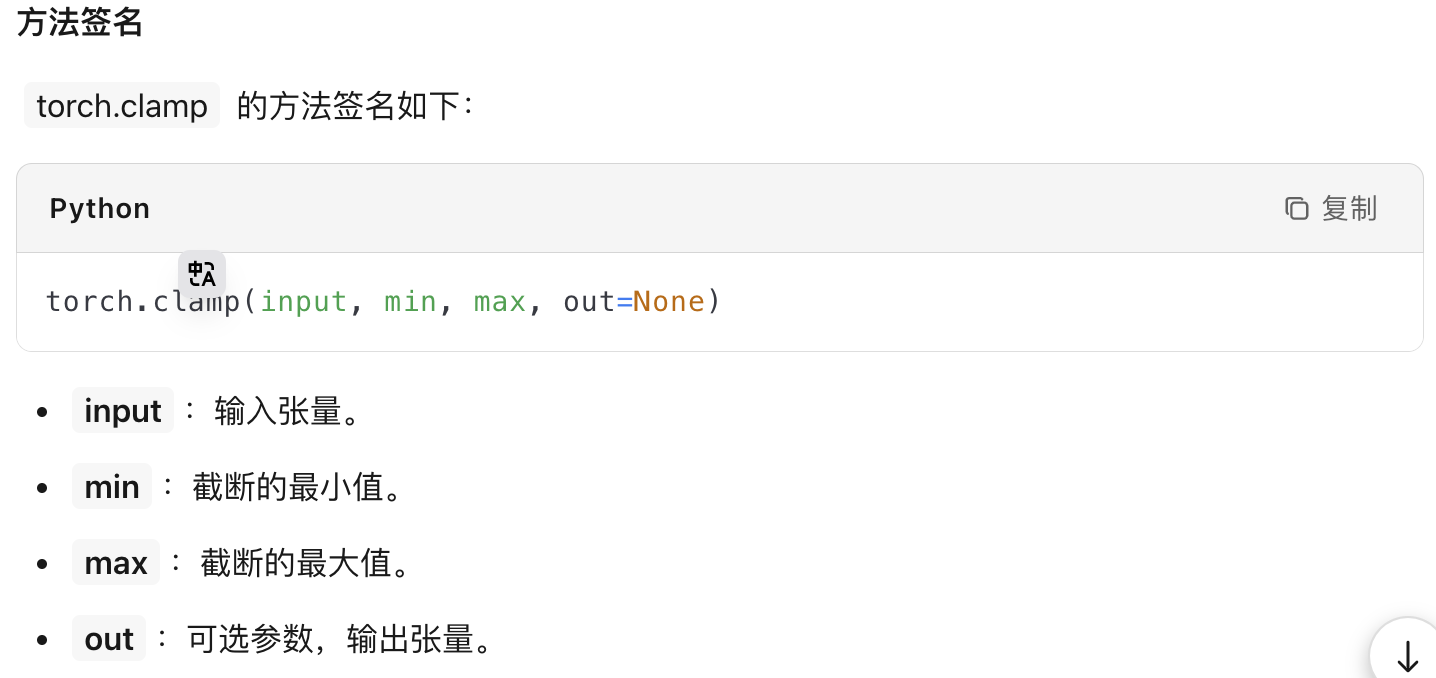

In [120]:
Image(filename='./Image/torch.clamp.png',width=600)

In [ ]:
import torch

# 创建一个张量
x = torch.tensor([-1.0, 0.5, 2.0, 3.5])

# 将张量中的每个元素限制在 [0, 2] 范围内
y = torch.clamp(x, min=0, max=2)

print(y)
# 输出: tensor([0., 0.5, 2., 2.])

In [ ]:
# 示例 2：使用标量作为最小值和最大值

import torch

# 创建一个张量
x = torch.tensor([-1.0, 0.5, 2.0, 3.5])

# 将张量中的每个元素限制在 [0, 2] 范围内
y = torch.clamp(x, min=0, max=2)

print(y)
# 输出: tensor([0., 0.5, 2., 2.])

In [ ]:
# 示例 3：使用张量作为最小值和最大值
# 创建一个张量
x = torch.tensor([-1.0, 0.5, 2.0, 3.5])

# 创建最小值和最大值张量
min_val = torch.tensor([-0.5, 0.0, 1.0, 2.0])
max_val = torch.tensor([0.5, 1.0, 2.5, 3.0])

# 将张量中的每个元素限制在 min_val 和 max_val 之间
y = torch.clamp(x, min=min_val, max=max_val)

print(y)
# 输出: tensor([-0.5, 0.5, 2.0, 3.0])